<a href="https://colab.research.google.com/github/JonathanPuertaG/challenge-telecom-x-parte-2/blob/main/Telecom_X2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**📌 Extracción**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv("/content/datos_tratados.csv")
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,rango_tenure
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,7-12
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,7-12
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,0-6
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,13-24
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,0-6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 


##** Preparación de los datos**

In [6]:
df = df.drop(['customerID', 'rango_tenure', 'Cuentas_Diarias'], axis=1)

In [7]:
df.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total'],
      dtype='object')

In [8]:
cols_to_fix = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in cols_to_fix:
    if col in df.columns:
        display(df[col].value_counts(dropna=False))
        display("-" * 30)

,count
PhoneService,
Yes,6352
No,680


'------------------------------'

,count
MultipleLines,
No,3385
Yes,2967
No phone service,680


'------------------------------'

,count
InternetService,
Fiber optic,3096
DSL,2416
No,1520


...

'------------------------------'

,count
PaperlessBilling,
Yes,4168
No,2864


'------------------------------'

,count
PaymentMethod,
Electronic check,2365
Mailed check,1604
Bank transfer (automatic),1542
Credit card (automatic),1521


'------------------------------'

In [9]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df_clean = df.copy()

for col in cols_to_fix:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace('No internet service', 'No')

categorical_cols = [
    'Churn', 'gender', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

*italicized text*### Encoding

In [29]:
columnas_categoricas_clean = df_clean.select_dtypes(include='object').columns.tolist()
columnas_categoricas_clean.remove('Churn')

df_codificado_clean = pd.get_dummies(df_clean, columns=columnas_categoricas_clean, drop_first=True)

df_codificado_clean['Churn'] = df_codificado_clean['Churn'].map({'No': 0, 'Yes': 1})
df_codificado_clean.info()
df_codificado_clean

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   tenure                                 7032 non-null   int64  
 3   Charges.Monthly                        7032 non-null   float64
 4   Charges.Total                          7032 non-null   float64
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  Inte

,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65.60,593.30,False,True,True,True,False,...,False,True,True,False,True,False,True,False,False,True
1,0,0,9,59.90,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.90,280.85,True,False,False,True,False,...,True,False,False,False,False,False,True,False,True,False
3,1,1,13,98.00,1237.85,True,True,False,True,False,...,True,False,True,True,False,False,True,False,True,False
4,1,1,3,83.90,267.40,False,True,False,True,False,...,False,True,True,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,0,13,55.15,742.90,False,False,False,True,False,...,False,True,False,False,True,False,False,False,False,True
7028,1,0,22,85.10,1873.70,True,True,False,True,False,...,False,False,False,True,False,False,True,False,True,False
7029,0,0,2,50.30,92.75,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
7030,0,0,67,67.85,4627.65,True,True,True,True,False,...,True,True,False,True,False,True,False,False,False,True


### ◔ Calcular la proporción de clientes que cancelaron

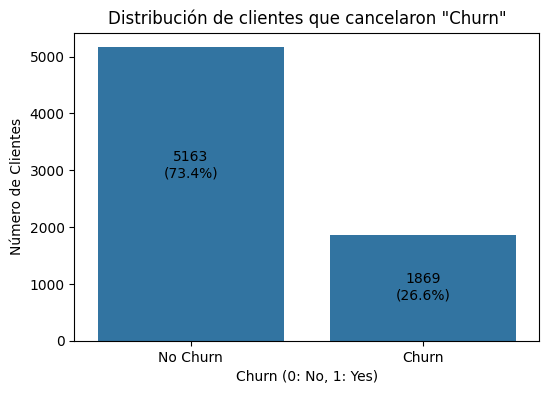

In [11]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df_codificado_clean)
plt.title('Distribución de clientes que cancelaron "Churn"')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Número de Clientes')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])

total = len(df_codificado_clean)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height * 0.65,
            '{:d}\n({:.1f}%)'.format(int(height), 100*height/total),
            ha="center", va="top") # Añade alineación vertical

plt.show()


### Análisis de Correlación

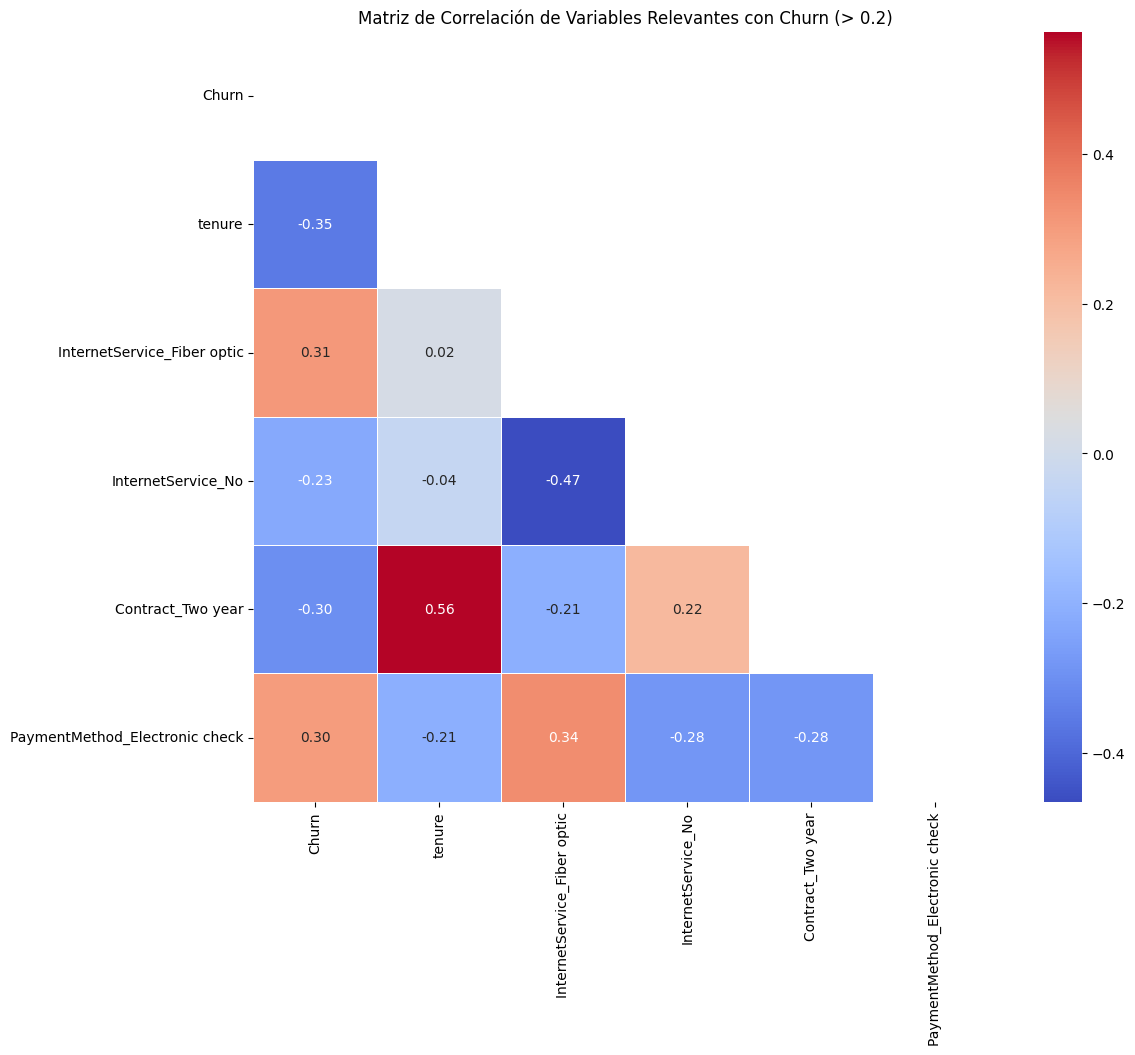

In [12]:
target_var = 'Churn'

limiar = 0.2

correlation_matrix_original = df_codificado_clean.corr()

variables_relevantes = correlation_matrix_original.index[abs(correlation_matrix_original[target_var]) >= limiar].tolist()

if target_var not in variables_relevantes:
    variables_relevantes.append(target_var)

corr_filtrada = correlation_matrix_original.loc[variables_relevantes, variables_relevantes]

mascara = np.triu(np.ones_like(corr_filtrada, dtype=bool))

plt.figure(figsize=(12,10))
sns.heatmap(corr_filtrada, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, mask=mascara)
plt.title('Matriz de Correlación de Variables Relevantes con Churn (> 0.2)')
plt.show()

bold text###  Balanceo de Clases

In [13]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_clean = df_codificado_clean[variables_relevantes].drop('Churn', axis=1)
y_clean = df_codificado_clean['Churn']

display("Distribución original de las clases (DataFrame limpio y codificado, variables relevantes):")
display(Counter(y_clean))

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(X_clean, y_clean, test_size=0.25, random_state=42, stratify=y_clean)

display("Dimensiones del conjunto de entrenamiento (X_train_clean, y_train_clean) antes del balanceo (variables relevantes):")
display(X_train_clean.shape, y_train_clean.shape)

display("Dimensiones del conjunto de prueba (X_test_clean, y_test_clean) antes del balanceo (variables relevantes):")
display(X_test_clean.shape, y_test_clean.shape)

smote_clean = SMOTE(random_state=42)
X_train_resampled_clean, y_train_resampled_clean = smote_clean.fit_resample(X_train_clean, y_train_clean)

display("Distribución de las clases en el conjunto de entrenamiento después de aplicar SMOTE (DataFrame limpio, variables relevantes):")
display(Counter(y_train_resampled_clean))

columnas_numericas_clean = X_train_resampled_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()


'Distribución original de las clases (DataFrame limpio y codificado, variables relevantes):'

Counter({0: 5163, 1: 1869})

'Dimensiones del conjunto de entrenamiento (X_train_clean, y_train_clean) antes del balanceo (variables relevantes):'

(5274, 5)

(5274,)

'Dimensiones del conjunto de prueba (X_test_clean, y_test_clean) antes del balanceo (variables relevantes):'

(1758, 5)

(1758,)

'Distribución de las clases en el conjunto de entrenamiento después de aplicar SMOTE (DataFrame limpio, variables relevantes):'

Counter({1: 3872, 0: 3872})

###  Estandarización de Características Numéricas

In [14]:

scaler_clean = StandardScaler()

X_train_resampled_clean[columnas_numericas_clean] = scaler_clean.fit_transform(X_train_resampled_clean[columnas_numericas_clean])


X_test_clean[columnas_numericas_clean] = scaler_clean.transform(X_test_clean[columnas_numericas_clean])


display("Primeras filas del conjunto de entrenamiento balanceado y estandarizado (DataFrame limpio, variables relevantes):")
display(X_train_resampled_clean.head())

display("Primeras filas del conjunto de prueba estandarizado (DataFrame limpio, variables relevantes):")
display(X_test_clean.head())

'Primeras filas del conjunto de entrenamiento balanceado y estandarizado (DataFrame limpio, variables relevantes):'

,tenure,InternetService_Fiber optic,InternetService_No,Contract_Two year,PaymentMethod_Electronic check
0,-0.703707,False,True,False,False
1,-0.703707,True,False,False,True
2,-0.745146,True,False,False,True
3,1.824086,False,False,True,False
4,-1.118099,True,False,False,False


'Primeras filas del conjunto de prueba estandarizado (DataFrame limpio, variables relevantes):'

,tenure,InternetService_Fiber optic,InternetService_No,Contract_Two year,PaymentMethod_Electronic check
876,-0.496511,True,False,False,False
527,-0.703707,False,False,False,False
4667,0.249395,True,False,False,False
4202,-1.076660,False,False,False,False
5760,-0.206436,True,False,False,True


###  Análisis de la Relación entre Variables Específicas y Churn

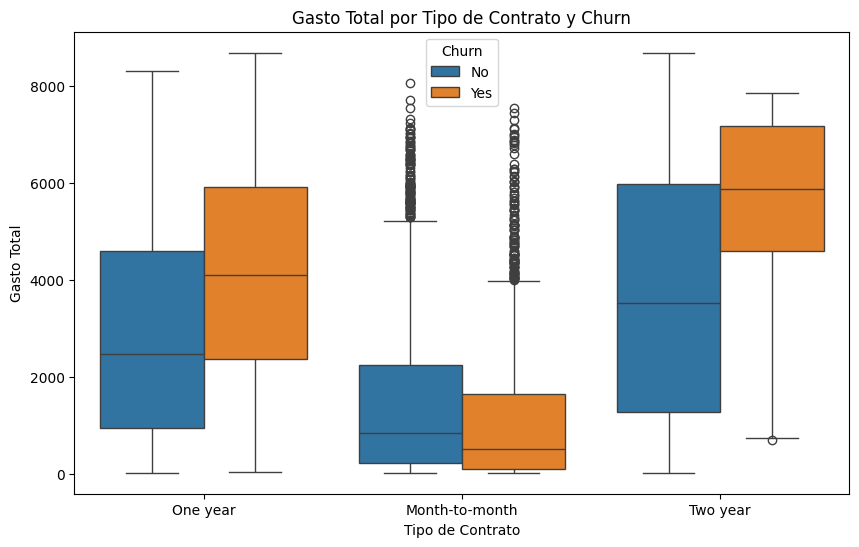

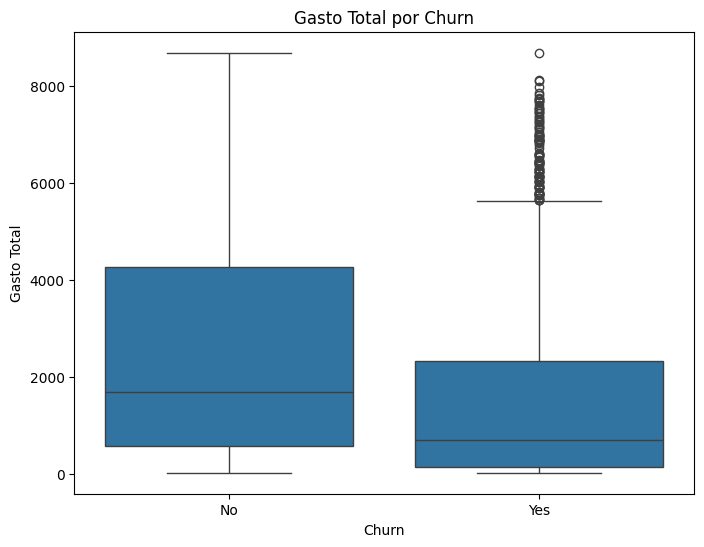

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
sns.boxplot(x='Contract', y='Charges.Total', hue='Churn', data=df_clean)
plt.title('Gasto Total por Tipo de Contrato y Churn')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Gasto Total')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Charges.Total', data=df_clean)
plt.title('Gasto Total por Churn')
plt.xlabel('Churn')
plt.ylabel('Gasto Total')
plt.show()

##  Modelado Predictivo

### Modelo Regresión Logística

'Evaluación del modelo de Regresión Logística (con datos limpios, balanceados y variables relevantes):'

'Accuracy: 0.7150'

'-------------------------------------------Reporte de Clasificación:--------------------------------------------'

,precision,recall,f1-score,support
0,0.903061,0.685515,0.779392,1291.000000
1,0.478149,0.796574,0.597590,467.000000
accuracy,0.715017,0.715017,0.715017,0.715017
macro avg,0.690605,0.741044,0.688491,1758.000000
weighted avg,0.790186,0.715017,0.731098,1758.000000


'-------------------------------------------Matriz de Confusión:--------------------------------------------'

,Predicción: No Churn (0),Predicción: Churn (1)
Valor Real: No Churn (0),885,406
Valor Real: Churn (1),95,372


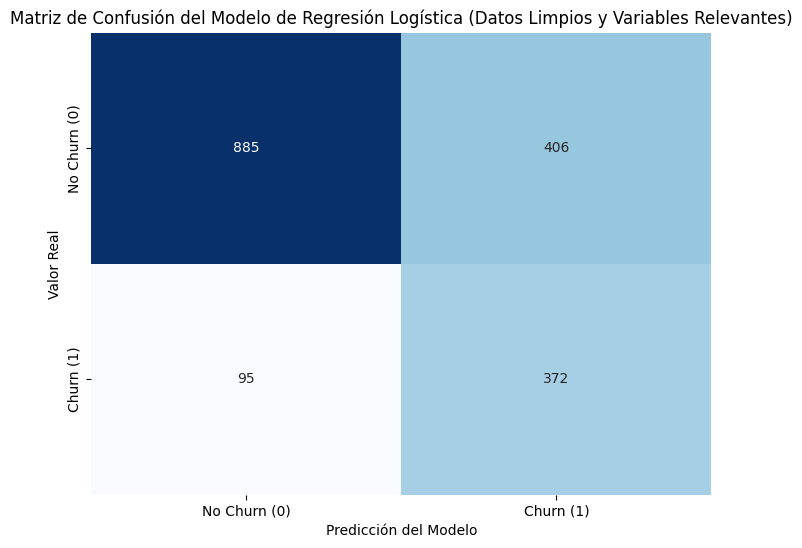

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

modelo_regresion_logistica_clean = LogisticRegression(random_state=42, solver='liblinear')

modelo_regresion_logistica_clean.fit(X_train_resampled_clean, y_train_resampled_clean)

y_pred_clean = modelo_regresion_logistica_clean.predict(X_test_clean)

display("Evaluación del modelo de Regresión Logística (con datos limpios, balanceados y variables relevantes):")
display(f"Accuracy: {accuracy_score(y_test_clean, y_pred_clean):.4f}")

reporte_clasificacion_dict = classification_report(y_test_clean, y_pred_clean, output_dict=True)
reporte_clasificacion_df = pd.DataFrame(reporte_clasificacion_dict).transpose()
display("-------------------------------------------Reporte de Clasificación:--------------------------------------------")
display(reporte_clasificacion_df)

cm_clean = confusion_matrix(y_test_clean, y_pred_clean)

cm_df = pd.DataFrame(cm_clean, index=['Valor Real: No Churn (0)', 'Valor Real: Churn (1)'], columns=['Predicción: No Churn (0)', 'Predicción: Churn (1)'])
display("-------------------------------------------Matriz de Confusión:--------------------------------------------")
display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión del Modelo de Regresión Logística (Datos Limpios y Variables Relevantes)')
plt.show()

*italicized text*###  Modelo Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

modelo_random_forest = RandomForestClassifier(random_state=42)

modelo_random_forest.fit(X_train_resampled_clean, y_train_resampled_clean)

y_pred_rf = modelo_random_forest.predict(X_test_clean)

display("Evaluación del modelo de Random Forest:")
display(f"Accuracy: {accuracy_score(y_test_clean, y_pred_rf):.4f}")

reporte_clasificacion_rf_dict = classification_report(y_test_clean, y_pred_rf, output_dict=True)
reporte_clasificacion_rf_df = pd.DataFrame(reporte_clasificacion_rf_dict).transpose()
display("-------------------------------------------Reporte de Clasificación (Random Forest):--------------------------------------------")
display(reporte_clasificacion_rf_df)

cm_rf = confusion_matrix(y_test_clean, y_pred_rf)

cm_rf_df = pd.DataFrame(cm_rf, index=['Valor Real: No Churn (0)', 'Valor Real: Churn (1)'], columns=['Predicción: No Churn (0)', 'Predicción: Churn (1)'])
display("-------------------------------------------Matriz de Confusión (Random Forest):--------------------------------------------")
display(cm_rf_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión del Modelo de Random Forest')
plt.show()

### 🚀Modelo XGBoost


In [18]:
# Instalar xgboost
%pip install xgboost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:48:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


'Evaluación del modelo XGBoost:'

'Accuracy: 0.6991'

'-------------------------------------------Reporte de Clasificación (XGBoost):--------------------------------------------'

,precision,recall,f1-score,support
0,0.885628,0.677769,0.767881,1291.00000
1,0.459740,0.758030,0.572352,467.00000
accuracy,0.699090,0.699090,0.699090,0.69909
macro avg,0.672684,0.717900,0.670117,1758.00000
weighted avg,0.772494,0.699090,0.715940,1758.00000


'-------------------------------------------Matriz de Confusión (XGBoost):--------------------------------------------'

,Predicción: No Churn (0),Predicción: Churn (1)
Valor Real: No Churn (0),875,416
Valor Real: Churn (1),113,354


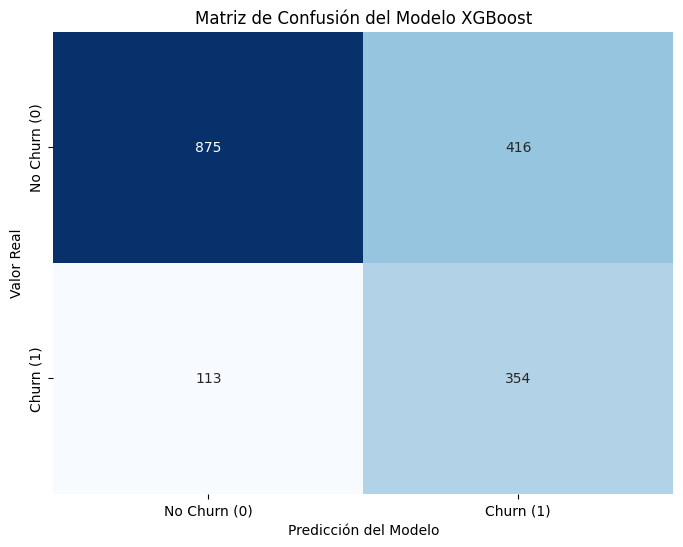

'AUC-ROC: 0.7998'

In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


modelo_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

modelo_xgb.fit(X_train_resampled_clean, y_train_resampled_clean)

# Predecir en el conjunto de prueba estandarizado
y_pred_xgb = modelo_xgb.predict(X_test_clean)

# Evaluar el modelo
display("Evaluación del modelo XGBoost:")
display(f"Accuracy: {accuracy_score(y_test_clean, y_pred_xgb):.4f}")

# Reporte de Clasificación en formato de tabla
reporte_clasificacion_xgb_dict = classification_report(y_test_clean, y_pred_xgb, output_dict=True)
reporte_clasificacion_xgb_df = pd.DataFrame(reporte_clasificacion_xgb_dict).transpose()
display("-------------------------------------------Reporte de Clasificación (XGBoost):--------------------------------------------")
display(reporte_clasificacion_xgb_df)

# Calcular la matriz de confusión
cm_xgb = confusion_matrix(y_test_clean, y_pred_xgb)

# Matriz de Confusión en formato de tabla
cm_xgb_df = pd.DataFrame(cm_xgb, index=['Valor Real: No Churn (0)', 'Valor Real: Churn (1)'], columns=['Predicción: No Churn (0)', 'Predicción: Churn (1)'])
display("-------------------------------------------Matriz de Confusión (XGBoost):--------------------------------------------")
display(cm_xgb_df)

# Crear la visualización de la matriz de confusión (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión del Modelo XGBoost')
plt.show()

# Calcular y mostrar el AUC-ROC
try:
    y_prob_xgb = modelo_xgb.predict_proba(X_test_clean)[:, 1]
    auc_roc_xgb = roc_auc_score(y_test_clean, y_prob_xgb)
    display(f"AUC-ROC: {auc_roc_xgb:.4f}")
except Exception as e:
    display(f"No se pudo calcular AUC-ROC: {e}")

## 🔍Evaluación de los Modelos

In [20]:
# Crear un diccionario para almacenar las métricas relevantes de cada modelo
comparacion_metricas = {
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test_clean, y_pred_clean),
                 accuracy_score(y_test_clean, y_pred_rf),
                 accuracy_score(y_test_clean, y_pred_xgb)],
    'Precision (Churn)': [reporte_clasificacion_dict['1']['precision'],
                          reporte_clasificacion_rf_dict['1']['precision'],
                          reporte_clasificacion_xgb_dict['1']['precision']],
    'Recall (Churn)': [reporte_clasificacion_dict['1']['recall'],
                       reporte_clasificacion_rf_dict['1']['recall'],
                       reporte_clasificacion_xgb_dict['1']['recall']],
    'F1-score (Churn)': [reporte_clasificacion_dict['1']['f1-score'],
                         reporte_clasificacion_rf_dict['1']['f1-score'],
                         reporte_clasificacion_xgb_dict['1']['f1-score']],
     'AUC-ROC': [roc_auc_score(y_test_clean, modelo_regresion_logistica_clean.predict_proba(X_test_clean)[:, 1]),
                roc_auc_score(y_test_clean, modelo_random_forest.predict_proba(X_test_clean)[:, 1]),
                roc_auc_score(y_test_clean, modelo_xgb.predict_proba(X_test_clean)[:, 1])]
}

# Crear un DataFrame con las métricas comparadas
df_comparacion = pd.DataFrame(comparacion_metricas)

# Formatear las columnas numéricas para mejor lectura
df_comparacion[['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1-score (Churn)', 'AUC-ROC']] = df_comparacion[['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1-score (Churn)', 'AUC-ROC']].map('{:.4f}'.format)

# Mostrar la tabla comparativa
display(df_comparacion)

,Modelo,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn),AUC-ROC
0,Regresión Logística,0.7150,0.4781,0.7966,0.5976,0.8223
1,Random Forest,0.6968,0.4567,0.7452,0.5663,0.7870
2,XGBoost,0.6991,0.4597,0.7580,0.5724,0.7998


### 🔍⚙️Evaluación de Modelos en el Conjunto de Entrenamiento

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd

# --- Evaluación del Modelo de Regresión Logística en Entrenamiento ---
display("Evaluación del modelo de Regresión Logística (Conjunto de Entrenamiento Balanceado):")

# Predicciones en el conjunto de entrenamiento
y_train_pred_lr = modelo_regresion_logistica_clean.predict(X_train_resampled_clean)

# Métricas
display(f"Accuracy: {accuracy_score(y_train_resampled_clean, y_train_pred_lr):.4f}")
reporte_entrenamiento_lr_dict = classification_report(y_train_resampled_clean, y_train_pred_lr, output_dict=True)
reporte_entrenamiento_lr_df = pd.DataFrame(reporte_entrenamiento_lr_dict).transpose()
display("Reporte de Clasificación:")
display(reporte_entrenamiento_lr_df)

# AUC-ROC en entrenamiento
y_train_prob_lr = modelo_regresion_logistica_clean.predict_proba(X_train_resampled_clean)[:, 1]
auc_roc_train_lr = roc_auc_score(y_train_resampled_clean, y_train_prob_lr)
display(f"AUC-ROC: {auc_roc_train_lr:.4f}")

display("-" * 50)

# --- Evaluación del Modelo Random Forest en Entrenamiento ---
display("Evaluación del modelo Random Forest (Conjunto de Entrenamiento Balanceado):")

# Predicciones en el conjunto de entrenamiento
y_train_pred_rf = modelo_random_forest.predict(X_train_resampled_clean)

# Métricas
display(f"Accuracy: {accuracy_score(y_train_resampled_clean, y_train_pred_rf):.4f}")
reporte_entrenamiento_rf_dict = classification_report(y_train_resampled_clean, y_train_pred_rf, output_dict=True)
reporte_entrenamiento_rf_df = pd.DataFrame(reporte_entrenamiento_rf_dict).transpose()
display("Reporte de Clasificación:")
display(reporte_entrenamiento_rf_df)

# AUC-ROC en entrenamiento
y_train_prob_rf = modelo_random_forest.predict_proba(X_train_resampled_clean)[:, 1]
auc_roc_train_rf = roc_auc_score(y_train_resampled_clean, y_train_prob_rf)
display(f"AUC-ROC: {auc_roc_train_rf:.4f}")

display("-" * 50)

# --- Evaluación del Modelo XGBoost en Entrenamiento ---
display("Evaluación del modelo XGBoost (Conjunto de Entrenamiento Balanceado):")

# Predicciones en el conjunto de entrenamiento
y_train_pred_xgb = modelo_xgb.predict(X_train_resampled_clean)

# Métricas
display(f"Accuracy: {accuracy_score(y_train_resampled_clean, y_train_pred_xgb):.4f}")
reporte_entrenamiento_xgb_dict = classification_report(y_train_resampled_clean, y_train_pred_xgb, output_dict=True)
reporte_entrenamiento_xgb_df = pd.DataFrame(reporte_entrenamiento_xgb_dict).transpose()
display("Reporte de Clasificación:")
display(reporte_entrenamiento_xgb_df)

# AUC-ROC en entrenamiento
y_train_prob_xgb = modelo_xgb.predict_proba(X_train_resampled_clean)[:, 1]
auc_roc_train_xgb = roc_auc_score(y_train_resampled_clean, y_train_prob_xgb)
display(f"AUC-ROC: {auc_roc_train_xgb:.4f}")

display("-" * 50)

'Evaluación del modelo de Regresión Logística (Conjunto de Entrenamiento Balanceado):'

'Accuracy: 0.7517'

'Reporte de Clasificación:'

,precision,recall,f1-score,support
0,0.776768,0.706353,0.739889,3872.000000
1,0.730760,0.797004,0.762446,3872.000000
accuracy,0.751679,0.751679,0.751679,0.751679
macro avg,0.753764,0.751679,0.751168,7744.000000
weighted avg,0.753764,0.751679,0.751168,7744.000000


'AUC-ROC: 0.8354'

...

'Accuracy: 0.7976'

'Reporte de Clasificación:'

,precision,recall,f1-score,support
0,0.847662,0.725723,0.781967,3872.00000
1,0.760217,0.869576,0.811228,3872.00000
accuracy,0.797650,0.797650,0.797650,0.79765
macro avg,0.803939,0.797650,0.796598,7744.00000
weighted avg,0.803939,0.797650,0.796598,7744.00000


'AUC-ROC: 0.8762'

'--------------------------------------------------'

### 🔍🔄Validación Cruzada

In [22]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# Definir las métricas a evaluar
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True) # AUC-ROC necesita probabilidades
}

# Inicializar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Convertir columnas booleanas a enteros en X_clean para evitar errores de tipo
X_clean_processed = X_clean.copy()
for col in X_clean_processed.select_dtypes(include='bool').columns:
    X_clean_processed[col] = X_clean_processed[col].astype(int)


# --- Validación Cruzada para Regresión Logística ---
display("Validación Cruzada (K=5) para Regresión Logística:")
# Re-inicializar el modelo para asegurar que no haya aprendizaje previo del entrenamiento completo
modelo_lr_cv = LogisticRegression(random_state=42, solver='liblinear')

# Usamos X_clean_processed aquí
cv_results_lr = cross_val_score(modelo_lr_cv, X_clean_processed, y_clean, cv=kf, scoring='roc_auc') # Usamos AUC-ROC para CV inicial
display(f"AUC-ROC promedio (CV): {np.mean(cv_results_lr):.4f}")
display(f"AUC-ROC desviación estándar (CV): {np.std(cv_results_lr):.4f}")

display("-" * 50)

# --- Validación Cruzada para Random Forest ---
display("Validación Cruzada (K=5) para Random Forest:")
# Re-inicializar el modelo
modelo_rf_cv = RandomForestClassifier(random_state=42)

# Usamos X_clean_processed aquí
cv_results_rf = cross_val_score(modelo_rf_cv, X_clean_processed, y_clean, cv=kf, scoring='roc_auc') # Usamos AUC-ROC para CV inicial
display(f"AUC-ROC promedio (CV): {np.mean(cv_results_rf):.4f}")
display(f"AUC-ROC desviación estándar (CV): {np.std(cv_results_rf):.4f}")

display("-" * 50)

# --- Validación Cruzada para XGBoost ---
display("Validación Cruzada (K=5) para XGBoost:")
# Re-inicializar el modelo
modelo_xgb_cv = XGBClassifier(random_state=42, use_label_encoder=False)

# Usamos X_clean_processed aquí
cv_results_xgb = cross_val_score(modelo_xgb_cv, X_clean_processed, y_clean, cv=kf, scoring='roc_auc') # Usamos AUC-ROC para CV inicial
display(f"AUC-ROC promedio (CV): {np.mean(cv_results_xgb):.4f}")
display(f"AUC-ROC desviación estándar (CV): {np.std(cv_results_xgb):.4f}")

display("-" * 50)

# NOTA: Para obtener todas las métricas (precision, recall, etc.) con cross_val_score,
# se necesitaría usar cross_validate en lugar de cross_val_score y especificar el diccionario 'scoring'.
# cross_validate devuelve un diccionario con los resultados de cada métrica para cada fold.
# Por simplicidad inicial, mostramos el AUC-ROC promedio con cross_val_score.
# Si deseas ver el código para cross_validate con todas las métricas, házmelo saber.

'Validación Cruzada (K=5) para Regresión Logística:'

'AUC-ROC promedio (CV): 0.8306'

'AUC-ROC desviación estándar (CV): 0.0139'

'--------------------------------------------------'

'Validación Cruzada (K=5) para Random Forest:'

...

'Validación Cruzada (K=5) para XGBoost:'

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:49:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:49:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:49:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:49:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

'AUC-ROC promedio (CV): 0.8205'

'AUC-ROC desviación estándar (CV): 0.0108'

'--------------------------------------------------'

## 📋 Interpretación y Conclusiones

### ⭐Análisis de la Importancia de las Variables

#### 1. Importancia de las variables para la regresión logística



In [23]:
# Obtener los coeficientes del modelo de Regresión Logística
coeficientes_lr = modelo_regresion_logistica_clean.coef_[0]

# Obtener los nombres de las columnas (variables) que se usaron para entrenar el modelo
nombres_variables = X_train_resampled_clean.columns

# Crear un DataFrame para mostrar los coeficientes y la importancia (valor absoluto)
importancia_lr = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes_lr,
    'Importancia Absoluta': np.abs(coeficientes_lr)
})

# Ordenar por importancia absoluta descendente
importancia_lr = importancia_lr.sort_values(by='Importancia Absoluta', ascending=False)

# Mostrar la tabla de importancia de variables
display("Importancia de las Variables (Regresión Logística - Coeficientes):")
display(importancia_lr)



'Importancia de las Variables (Regresión Logística - Coeficientes):'

,Variable,Coeficiente,Importancia Absoluta
3,Contract_Two year,-1.605899,1.605899
2,InternetService_No,-1.265741,1.265741
1,InternetService_Fiber optic,1.082561,1.082561
0,tenure,-0.845506,0.845506
4,PaymentMethod_Electronic check,0.489988,0.489988


#### 2. Importancia de las variables para Random Forest


'Importancia de las Variables (Random Forest):'

,Variable,Importancia
0,tenure,0.486633
3,Contract_Two year,0.215367
1,InternetService_Fiber optic,0.152438
2,InternetService_No,0.073600
4,PaymentMethod_Electronic check,0.071963


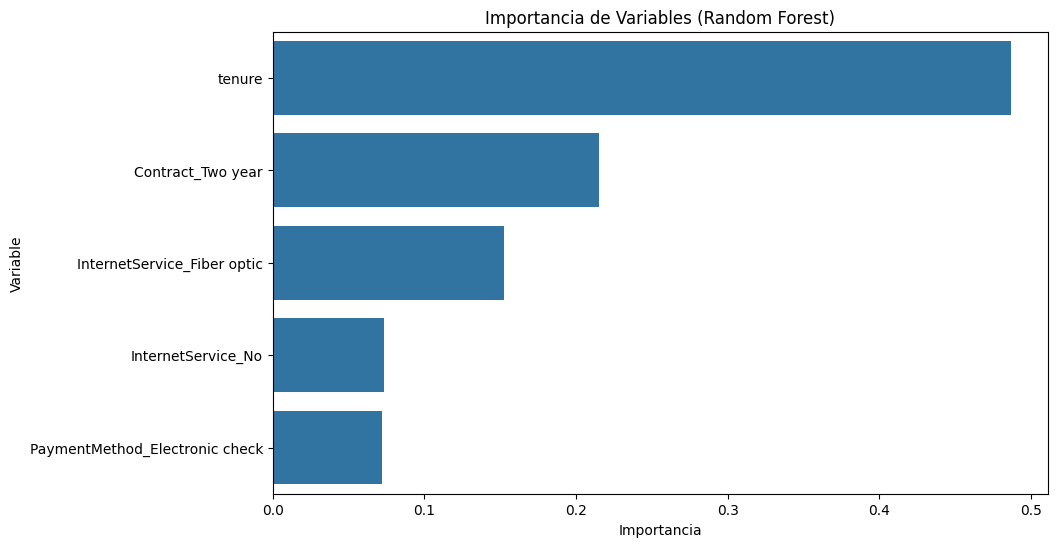

In [24]:
# Obtener la importancia de las características del modelo Random Forest
importancia_rf = modelo_random_forest.feature_importances_

# Obtener los nombres de las columnas (variables)
nombres_variables = X_train_resampled_clean.columns

# Crear un DataFrame para mostrar la importancia de las variables
importancia_rf_df = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancia_rf
})

# Ordenar por importancia descendente
importancia_rf_df = importancia_rf_df.sort_values(by='Importancia', ascending=False)

# Mostrar la tabla de importancia de variables
display("Importancia de las Variables (Random Forest):")
display(importancia_rf_df)

# Opcional: Visualizar la importancia
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancia_rf_df)
plt.title('Importancia de Variables (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

#### 3. Importancia de las variables para XGBoost


'Importancia de las Variables (XGBoost):'

,Variable,Importancia
3,Contract_Two year,0.668598
2,InternetService_No,0.133129
1,InternetService_Fiber optic,0.115466
0,tenure,0.056516
4,PaymentMethod_Electronic check,0.026292


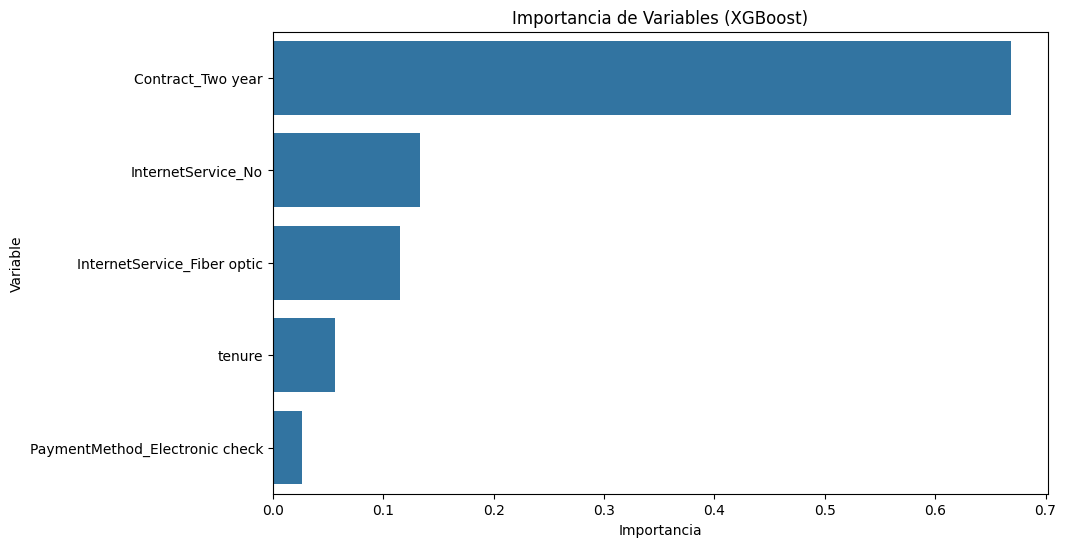

In [25]:
# Obtener la importancia de las características del modelo XGBoost
importancia_xgb = modelo_xgb.feature_importances_

# Obtener los nombres de las columnas (variables)
nombres_variables = X_train_resampled_clean.columns

# Crear un DataFrame para mostrar la importancia de las variables
importancia_xgb_df = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancia_xgb
})

# Ordenar por importancia descendente
importancia_xgb_df = importancia_xgb_df.sort_values(by='Importancia', ascending=False)

# Mostrar la tabla de importancia de variables
display("Importancia de las Variables (XGBoost):")
display(importancia_xgb_df)

# Opcional: Visualizar la importancia
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancia_xgb_df)
plt.title('Importancia de Variables (XGBoost)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

In [26]:
display("Importancia de las Variables (Regresión Logística - Coeficientes):")
display(importancia_lr)

'Importancia de las Variables (Regresión Logística - Coeficientes):'

,Variable,Coeficiente,Importancia Absoluta
3,Contract_Two year,-1.605899,1.605899
2,InternetService_No,-1.265741,1.265741
1,InternetService_Fiber optic,1.082561,1.082561
0,tenure,-0.845506,0.845506
4,PaymentMethod_Electronic check,0.489988,0.489988


**Random Forest:**

In [27]:
display("Importancia de las Variables (Random Forest):")
display(importancia_rf_df)

'Importancia de las Variables (Random Forest):'

,Variable,Importancia
0,tenure,0.486633
3,Contract_Two year,0.215367
1,InternetService_Fiber optic,0.152438
2,InternetService_No,0.073600
4,PaymentMethod_Electronic check,0.071963


**XGBoost:**

In [28]:
display("Importancia de las Variables (XGBoost):")
display(importancia_xgb_df)

'Importancia de las Variables (XGBoost):'

,Variable,Importancia
3,Contract_Two year,0.668598
2,InternetService_No,0.133129
1,InternetService_Fiber optic,0.115466
0,tenure,0.056516
4,PaymentMethod_Electronic check,0.026292


### ✅ Conclusiones